<a href="https://colab.research.google.com/github/aseda-wrok/rice-variety-clasification/blob/main/AI_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

In [ ]:
files.upload()

In [ ]:
import os
import subprocess # Add this import

os.makedirs("/root/.kaggle", exist_ok=True)
os.system("cp \"kaggle (1) (2).json\" /root/.kaggle/kaggle.json")
os.system("chmod 600 /root/.kaggle/kaggle.json")
os.system("pip install -q kaggle")

KAGGLE_DATASET_SLUG = "muratkokludataset/rice-image-dataset"
DEST_DIR = "data"
if __name__ == "__main__":
    os.makedirs(DEST_DIR, exist_ok=True)
    command = f"kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p {DEST_DIR} --unzip"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    exit_code = result.returncode

    if exit_code != 0:
        print("Kaggle command failed. Here's the output:")
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
        raise SystemExit(
            "Kaggle download failed. Check that kaggle.json is in place and "
            "that KAGGLE_DATASET_SLUG matches the dataset URL exactly. "
            "Please check the printed STDOUT/STDERR for more details."
        )
print(f"Dataset downloaded and unzipped into '{DEST_DIR}/'")
print("Contents:")
for root, dirs, files in os.walk(DEST_DIR):
        level = root.replace(DEST_DIR, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 2:
            for f in files[:5]:
                print(f"{indent}  {f}")


Dataset downloaded and unzipped into 'data/'
Contents:
data/
  Rice_Image_Dataset/
    Rice_Citation_Request.txt
    Karacadag/
    Jasmine/
    Ipsala/
    Basmati/
    Arborio/


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# 1. CONFIG — adjust these for your dataset
DATA_DIR = "data/Rice_Image_Dataset"
TEST_DIR = "data/test"
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 16
EPOCHS = 15
VALIDATION_SPLIT = 0.2
SEED = 42
OUTPUT_DIR = "outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
import math
# 2. LOAD THE DATA with ImageDataGenerator
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

# Only rescaling for validation and test data
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VALIDATION_SPLIT
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    subset='training',
    seed=SEED,
    class_mode='sparse'
)

# Validation data generator
val_generator = val_test_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=SEED,
    class_mode='sparse'
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Classes found: {class_names}")

# Use a separate held-out test set if provided, else reuse validation for final eval
if TEST_DIR and os.path.isdir(TEST_DIR):
    test_generator = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        shuffle=False,
        class_mode='sparse'
    )
else:
    test_generator = val_generator

# Calculate steps per epoch
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(val_generator.samples / BATCH_SIZE)


Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.
Classes found: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [ ]:
# 4. BUILD THE CNN
model = models.Sequential([
    layers.Conv2D(32, 3, padding="same", activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
], name="image_cnn")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "image_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
import os

OUTPUT_DIR = "outputs" # Define OUTPUT_DIR here to ensure it's available

# 5. TRAIN
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_model.keras"), save_best_only=True
    ),
]

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 344s 90ms/step - accuracy: 0.9374 - loss: 0.1721 - val_accuracy: 0.9921 - val_loss: 0.0215
Epoch 2/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 331s 88ms/step - accuracy: 0.9820 - loss: 0.0553 - val_accuracy: 0.9927 - val_loss: 0.0218
Epoch 3/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 329s 88ms/step - accuracy: 0.9862 - loss: 0.0450 - val_accuracy: 0.9887 - val_loss: 0.0363
Epoch 4/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 334s 89ms/step - accuracy: 0.9870 - loss: 0.0411 - val_accuracy: 0.9935 - val_loss: 0.0203
Epoch 5/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 330s 88ms/step - accuracy: 0.9876 - loss: 0.0392 - val_accuracy: 0.9951 - val_loss: 0.0154
Epoch 6/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 333s 89ms/step - accuracy: 0.9888 - loss: 0.0359 - val_accuracy: 0.9953 - val_loss: 0.0165
Epoch 7/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 332s 89ms/step - accuracy: 0.9899 - loss: 0.0344 - val_accuracy: 0.9955 - val_loss: 0.0138
Epoch 8/15
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 330s 88ms/step - accuracy: 

In [ ]:
# 6. EVALUATE
# Ensure test_generator is reset before evaluation/prediction
test_generator.reset()

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

# Reset generator again before prediction to ensure it starts from the beginning
test_generator.reset()

# Get predictions
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Construct y_true from filenames to ensure perfect alignment with predictions
y_true_from_filenames = []
for filename in test_generator.filenames:
    # Extract class name from filename (e.g., 'Arborio/image.jpg' -> 'Arborio')
    class_name = filename.split(os.sep)[0]
    y_true_from_filenames.append(test_generator.class_indices[class_name])
y_true = np.array(y_true_from_filenames)

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=class_names))

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump({"test_accuracy": test_acc, "test_loss": test_loss, "report": report}, f, indent=2)


938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9955 - loss: 0.0138
Test accuracy: 0.9955 | Test loss: 0.0138
              precision    recall  f1-score   support

     Arborio       0.20      0.20      0.20      3000
     Basmati       0.20      0.19      0.20      3000
      Ipsala       0.20      0.20      0.20      3000
     Jasmine       0.20      0.20      0.20      3000
   Karacadag       0.19      0.19      0.19      3000

    accuracy                           0.20     15000
   macro avg       0.20      0.20      0.20     15000
weighted avg       0.20      0.20      0.20     15000



Saved model, metrics, and plots to 'outputs/'


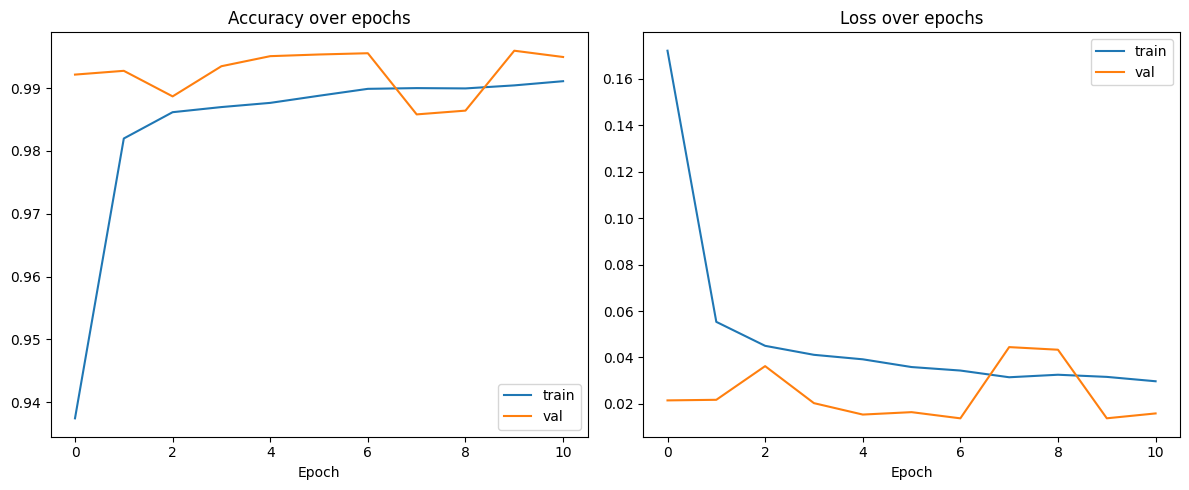

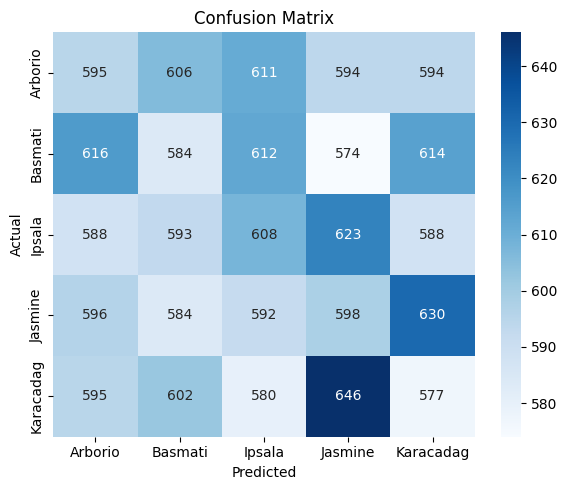

In [ ]:
# 7. PLOTS — training curves + confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
# Removed plt.close() to display the plot

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
# Removed plt.close() to display the plot

print(f"Saved model, metrics, and plots to '{OUTPUT_DIR}/'")

In [ ]:
!git clone https://github.com/your-username/your-repository.git